<a href="https://colab.research.google.com/github/Arexreva/Arexprix/blob/main/Artificial_Intelligence_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ All libraries imported successfully!

✅ Dataset created! First 5 rows:
   Feature1  Feature2  cluster
0 -7.338988 -7.729954        2
1 -7.740041 -7.264665        2
2 -1.686653  7.793442        0
3  4.422198  3.071947        1
4 -8.917752 -7.888196        2

Total rows: 300
Columns: ['Feature1', 'Feature2', 'cluster']


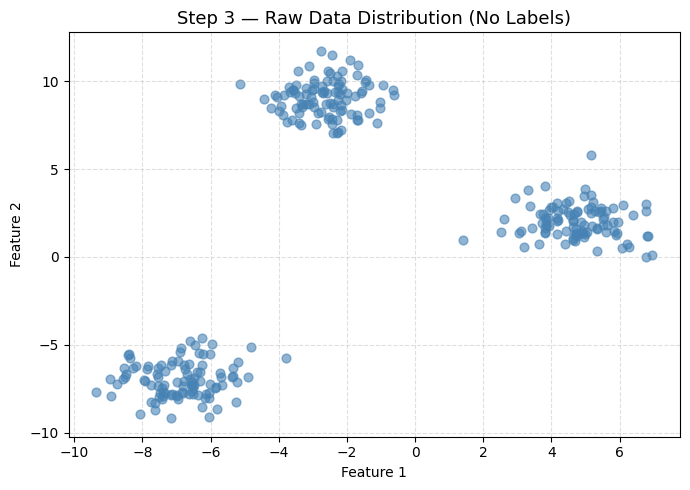

✅ Raw data plot saved as raw_data_plot.png

✅ K-Means fitted!
Labels assigned (first 10): [1 1 0 2 1 2 0 2 0 0]


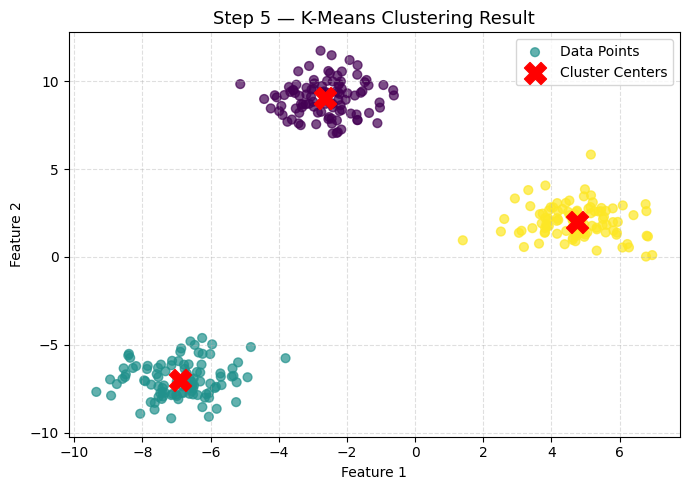

✅ K-Means cluster plot saved!

✅ Cluster Centers (x, y positions):
  Cluster 0: Feature1=-2.63, Feature2=9.04
  Cluster 1: Feature1=-6.88, Feature2=-6.98
  Cluster 2: Feature1=4.75, Feature2=2.01

Inertia (within-cluster sum of squares): 566.86
→ Lower inertia means tighter, better-defined clusters.


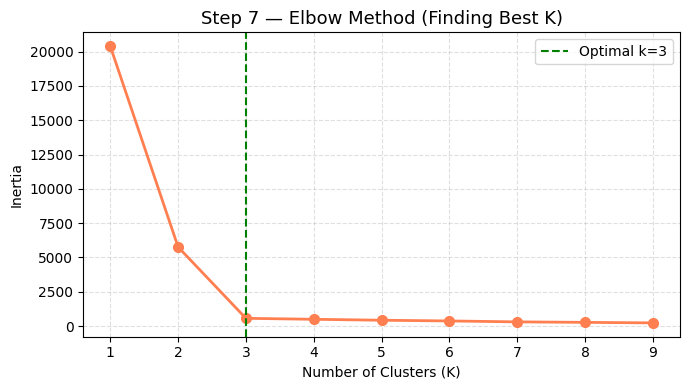

✅ Elbow method plot saved! (Bonus analysis)

✅ PCA Applied!
Original shape:  (300, 2)  → (300 rows, 2 features)
Reduced shape:   (300, 2) → same here since already 2D

Explained Variance Ratio: [0.74600765 0.25399235]
PC1 explains: 74.6% of variance
PC2 explains: 25.4% of variance
Total kept:   100.0%


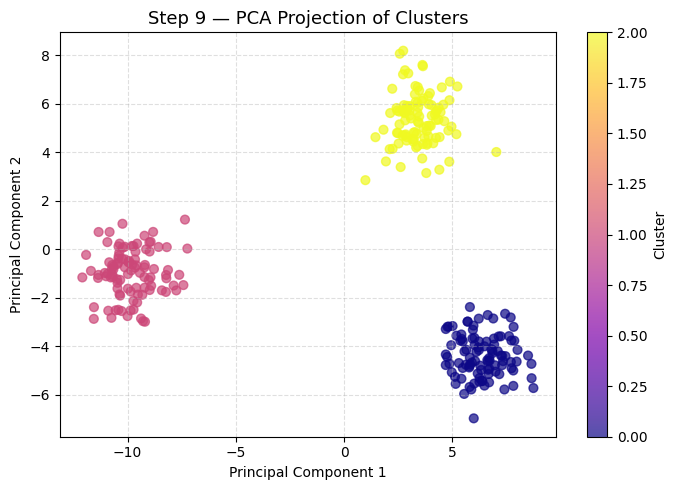

✅ PCA projection plot saved!


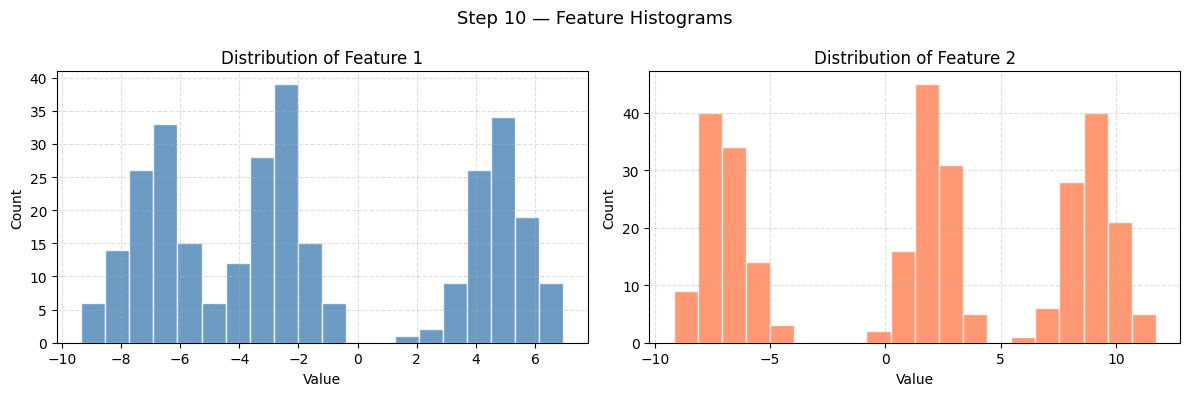

✅ Histograms saved!

✅ Data split complete!
Training samples: 240  (80%)
Testing samples:  60   (20%)

✅ Neural Network trained successfully!
Number of layers: 4
Number of iterations run: 185

✅ Predictions made on test set!

  NEURAL NETWORK ACCURACY: 100.00%

Detailed Classification Report:
              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00        18
   Cluster 1       1.00      1.00      1.00        17
   Cluster 2       1.00      1.00      1.00        25

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



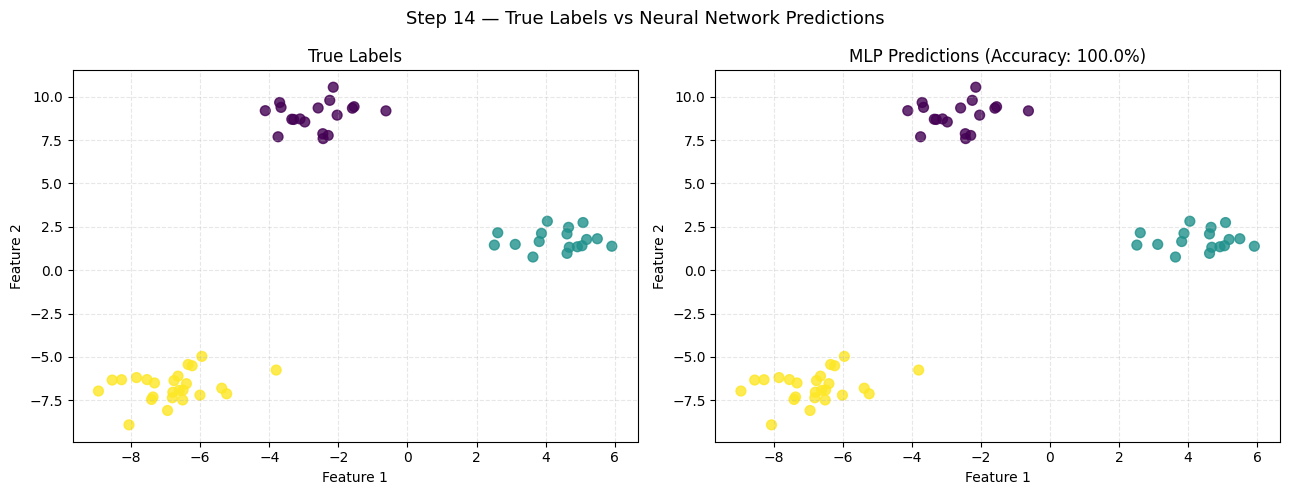

✅ Comparison plot saved!

   FINAL PROJECT SUMMARY
  Dataset Size        : 300 samples, 3 clusters
  K-Means Inertia     : 566.86
  PCA Variance Kept   : 100.0%
  Train/Test Split    : 240 / 60 samples
  MLP Architecture    : Input → 10 → 10 → Output
  Neural Net Accuracy : 100.00%

✅ Project complete! All plots saved.
   Files saved: raw_data_plot.png, kmeans_clusters.png,
   elbow_method.png, pca_projection.png,
   feature_histograms.png, true_vs_predicted.png


In [3]:
# ============================================================
#   AI LAB EXERCISE 11 — Complete Project
#   Clustering, PCA and Neural Network
#   Run this file in Google Colab — Step by Step
# ============================================================

# ──────────────────────────────────────────────
# STEP 1 — Install & Import All Libraries
# ──────────────────────────────────────────────
# In Google Colab, these are already installed.
# Just run this cell first.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

print("✅ All libraries imported successfully!")


# ──────────────────────────────────────────────
# STEP 2 — Generate the Dataset
# ──────────────────────────────────────────────
# make_blobs creates fake clustered data points.
# n_samples = total number of data points
# centers   = number of clusters
# random_state = seed so results are same every time

X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

# Convert to a DataFrame (table format)
data = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
data['cluster'] = y

print("\n✅ Dataset created! First 5 rows:")
print(data.head())
print(f"\nTotal rows: {len(data)}")
print(f"Columns: {list(data.columns)}")


# ──────────────────────────────────────────────
# STEP 3 — Visualize Raw Data (Before Clustering)
# ──────────────────────────────────────────────
# This shows the data BEFORE we apply any algorithm.
# We do NOT use colors here — we pretend we don't know the groups.

plt.figure(figsize=(7, 5))
plt.scatter(data['Feature1'], data['Feature2'], color='steelblue', alpha=0.6, s=40)
plt.title("Step 3 — Raw Data Distribution (No Labels)", fontsize=13)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("raw_data_plot.png", dpi=150)
plt.show()
print("✅ Raw data plot saved as raw_data_plot.png")


# ──────────────────────────────────────────────
# STEP 4 — Apply K-Means Clustering
# ──────────────────────────────────────────────
# K-Means finds groups in data WITHOUT using labels.
# n_clusters=3 means we want 3 groups.

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

# labels_ gives each data point a group number (0, 1, or 2)
labels = kmeans.labels_

print("\n✅ K-Means fitted!")
print(f"Labels assigned (first 10): {labels[:10]}")


# ──────────────────────────────────────────────
# STEP 5 — Visualize the Clusters
# ──────────────────────────────────────────────
# Now we color each point by its cluster number.
# Red X marks show the CENTER of each cluster.

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7, s=40, label='Data Points')
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=250, c='red', marker='X', zorder=5, label='Cluster Centers'
)
plt.title("Step 5 — K-Means Clustering Result", fontsize=13)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150)
plt.show()
print("✅ K-Means cluster plot saved!")


# ──────────────────────────────────────────────
# STEP 6 — Cluster Centers & Inertia (Analysis)
# ──────────────────────────────────────────────
# cluster_centers_ = coordinate of each cluster's center
# inertia_ = how tight/compact the clusters are (lower = better)

centers = kmeans.cluster_centers_
print("\n✅ Cluster Centers (x, y positions):")
for i, c in enumerate(centers):
    print(f"  Cluster {i}: Feature1={c[0]:.2f}, Feature2={c[1]:.2f}")

print(f"\nInertia (within-cluster sum of squares): {kmeans.inertia_:.2f}")
print("→ Lower inertia means tighter, better-defined clusters.")


# ──────────────────────────────────────────────
# STEP 7 — Elbow Method (BONUS — Impress Professor)
# ──────────────────────────────────────────────
# This finds the BEST number of clusters.
# We plot inertia for k=1 to k=9 and look for the "elbow".

inertia_values = []
k_range = range(1, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertia_values, marker='o', color='coral', linewidth=2, markersize=7)
plt.axvline(x=3, color='green', linestyle='--', label='Optimal k=3')
plt.title("Step 7 — Elbow Method (Finding Best K)", fontsize=13)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("elbow_method.png", dpi=150)
plt.show()
print("✅ Elbow method plot saved! (Bonus analysis)")


# ──────────────────────────────────────────────
# STEP 8 — PCA: Dimensionality Reduction
# ──────────────────────────────────────────────
# PCA compresses features while keeping key information.
# For 2D data it just rotates/aligns to best axes.
# Very useful when data has 10, 50, 100+ features.

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

print("\n✅ PCA Applied!")
print(f"Original shape:  {X.shape}  → (300 rows, 2 features)")
print(f"Reduced shape:   {X_reduced.shape} → same here since already 2D")
print(f"\nExplained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"PC1 explains: {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"Total kept:   {sum(pca.explained_variance_ratio_)*100:.1f}%")


# ──────────────────────────────────────────────
# STEP 9 — Visualize PCA Projection
# ──────────────────────────────────────────────

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap='plasma', alpha=0.7, s=40)
plt.colorbar(scatter, label='Cluster')
plt.title("Step 9 — PCA Projection of Clusters", fontsize=13)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("pca_projection.png", dpi=150)
plt.show()
print("✅ PCA projection plot saved!")


# ──────────────────────────────────────────────
# STEP 10 — Feature Histograms (Analytical)
# ──────────────────────────────────────────────
# Understand how each feature is distributed.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data['Feature1'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title("Distribution of Feature 1")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].hist(data['Feature2'], bins=20, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title("Distribution of Feature 2")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Step 10 — Feature Histograms", fontsize=13)
plt.tight_layout()
plt.savefig("feature_histograms.png", dpi=150)
plt.show()
print("✅ Histograms saved!")


# ──────────────────────────────────────────────
# STEP 11 — Train / Test Split
# ──────────────────────────────────────────────
# Split data: 80% for training, 20% for testing.
# The model learns on train data, evaluated on test data.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\n✅ Data split complete!")
print(f"Training samples: {len(X_train)}  (80%)")
print(f"Testing samples:  {len(X_test)}   (20%)")


# ──────────────────────────────────────────────
# STEP 12 — Build & Train Neural Network (MLP)
# ──────────────────────────────────────────────
# MLPClassifier = Multi-Layer Perceptron (basic neural network)
# hidden_layer_sizes=(10, 10) = 2 hidden layers, 10 neurons each
# max_iter=2000 = maximum training cycles

model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    max_iter=2000,
    random_state=42
)

model.fit(X_train, y_train)
print("\n✅ Neural Network trained successfully!")
print(f"Number of layers: {model.n_layers_}")
print(f"Number of iterations run: {model.n_iter_}")


# ──────────────────────────────────────────────
# STEP 13 — Make Predictions & Evaluate
# ──────────────────────────────────────────────

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\n✅ Predictions made on test set!")
print(f"\n{'='*40}")
print(f"  NEURAL NETWORK ACCURACY: {accuracy*100:.2f}%")
print(f"{'='*40}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, predictions,
      target_names=['Cluster 0', 'Cluster 1', 'Cluster 2']))


# ──────────────────────────────────────────────
# STEP 14 — Compare: True Labels vs Predicted
# ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', alpha=0.8, s=50)
axes[0].set_title("True Labels", fontsize=12)
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(True, linestyle='--', alpha=0.3)

axes[1].scatter(X_test[:, 0], X_test[:, 1], c=predictions, cmap='viridis', alpha=0.8, s=50)
axes[1].set_title(f"MLP Predictions (Accuracy: {accuracy*100:.1f}%)", fontsize=12)
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle("Step 14 — True Labels vs Neural Network Predictions", fontsize=13)
plt.tight_layout()
plt.savefig("true_vs_predicted.png", dpi=150)
plt.show()
print("✅ Comparison plot saved!")


# ──────────────────────────────────────────────
# STEP 15 — Final Summary
# ──────────────────────────────────────────────

print("\n" + "="*50)
print("   FINAL PROJECT SUMMARY")
print("="*50)
print(f"  Dataset Size        : 300 samples, 3 clusters")
print(f"  K-Means Inertia     : {kmeans.inertia_:.2f}")
print(f"  PCA Variance Kept   : {sum(pca.explained_variance_ratio_)*100:.1f}%")
print(f"  Train/Test Split    : 240 / 60 samples")
print(f"  MLP Architecture    : Input → 10 → 10 → Output")
print(f"  Neural Net Accuracy : {accuracy*100:.2f}%")
print("="*50)
print("\n✅ Project complete! All plots saved.")
print("   Files saved: raw_data_plot.png, kmeans_clusters.png,")
print("   elbow_method.png, pca_projection.png,")
print("   feature_histograms.png, true_vs_predicted.png")